# mastapy 초기화
mastapy를 사용하기 위해 설치된 경로 정보를 입력하고 mastapy를 초기화 하는 작업

In [2]:
# mastapy 초기화
import mastapy

mastapy.init(r'C:\Program Files\SMT\MASTA 13.0.3')

# Design 작성 및 열기

In [3]:
from mastapy.system_model import Design

# 새로운 Design 작성
my_design = Design()

# # 특정 파일 선택하여 열기
# my_design = Design.load(r'D:\sample_model\sample_model.Masta')

# # 예제파일 열기
# my_design = Design.load_example("Automotive: Scooter Gearbox")

# # 사용가능한 예제파일 리스트 확인
# available_examples = Design.available_examples
# print(available_examples)

# Exercise 1. Excel data를 이용한 Gear 작성 
Gearbox 모델링
모델링 항목
1. Shaft * 3
2. Gear set * 2
3. Bearing * 6

In [4]:
# 필요한 라이브러리 호출
from mastapy.bearings import BearingCatalog
import math
import pandas as pd
from openpyxl import load_workbook

# 단위 환산 준비
MM = 1e-3
RAD = math.pi/180
RPM = 2*math.pi/60

# Root assembly 변수에 할당
assembly = my_design.root_assembly

# Shaft 작성
1. 길이 및 위치 지정
2. 이름 변경

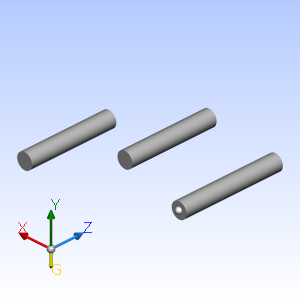

In [5]:
####################################################################################################
# Shaft
####################################################################################################
# Shaft1 작성
shaft1 = assembly.add_shaft(160*MM)

# Shaft2 작성
shaft2 = assembly.add_shaft(140*MM)
desiredPosition = mastapy._math.vector_3d.Vector3D(90,31.618,0)*MM
my_design.root_assembly.shafts[1].set_position_of_component_and_connected_components(desiredPosition)

# Shaft3 작성
shaft3 = assembly.add_shaft(140*MM)
desiredPosition = mastapy._math.vector_3d.Vector3D(210,0,-46.48)*MM
my_design.root_assembly.shafts[2].set_position_of_component_and_connected_components(desiredPosition)

# Shaft 이름 변경
shaft1.editable_name = "Shaft_1st"
shaft2.editable_name = "Shaft_2nd"
shaft3.editable_name = "Shaft_3rd"

assembly.three_d_isometric_view

# Bearing 작성
1. Concept bearing 작성
2. Bearing designation 지정
3. Bearing mounting 설정

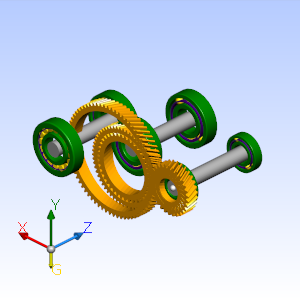

In [15]:
####################################################################################################
# Bearing 작성
####################################################################################################
# 1st shaft
# bearing_1st_L = assembly.add_bearing("Bearing_1st_L") #Concept 베어링 작성
bearing_1st_L = assembly.add_rolling_bearing_from_catalogue(BearingCatalog.SKF,'6306',"Bearing_1st_L") #Concept 베어링 작성
bearing_1st_R = assembly.add_rolling_bearing_from_catalogue(BearingCatalog.SKF,'6206','Bearing_1st_R' )
# 2nd shaft
bearing_2nd_L = assembly.add_rolling_bearing_from_catalogue(BearingCatalog.SKF,'6308','Bearing_2nd_L' )
bearing_2nd_R = assembly.add_rolling_bearing_from_catalogue(BearingCatalog.SKF,'6308','Bearing_2nd_R' )
# 3rd shaft
bearing_3rd_L = assembly.add_rolling_bearing_from_catalogue(BearingCatalog.TIMKEN,'350/352','Bearing_3rd_L' )
bearing_3rd_L.orientation = 0
bearing_3rd_R = assembly.add_rolling_bearing_from_catalogue(BearingCatalog.TIMKEN,'350/352','Bearing_3rd_R' )


# Bearing Mounting
shaft1.mount_component(bearing_1st_L, bearing_1st_L.length / 2.0)
shaft1.mount_component(bearing_1st_R, shaft1.length - bearing_1st_R.length / 2.0)

shaft2.mount_component(bearing_2nd_L, bearing_2nd_L.length / 2.0)
shaft2.mount_component(bearing_2nd_R, shaft2.length - bearing_2nd_R.length / 2.0)

shaft3.mount_component(bearing_3rd_L, bearing_3rd_L.length / 2.0)
shaft3.mount_component(bearing_3rd_R, shaft3.length - bearing_3rd_R.length / 2.0)

assembly.three_d_isometric_view

# Gearset 작성
1. Excel data를 활용한 Gear 작성
2. Gear mounting 설정

In [14]:
####################################################################################################
# Gearset 작성
####################################################################################################

#Excel file path
file_name = r'D:\NAS\KIMM\[외부 교육]\MASTA Training\GearSetImport_Single.xlsx'
wb = load_workbook(filename=file_name)  #read the file
sheets = wb.worksheets  #read the sheet name

file_data = pd.read_excel(file_name)  #Open as a Dataframe object
for gear_number in range(len(file_data.index)): #Creating first gear set
    gear_data = file_data.iloc[gear_number]
    gear_set = my_design.root_assembly.add_cylindrical_gear_pair(gear_data['Centre Distance']*MM)
    gear_set.editable_name = gear_data['Name']
    gear_set.active_gear_set_design.normal_module = gear_data['Normal Module']*MM
    gear_set.active_gear_set_design.helix_angle = gear_data['Helix Angle']*RAD
    gear_set.active_gear_set_design.normal_pressure_angle_maintain_transverse_profile = gear_data['Pressure Angle']*RAD
    gear_set.cylindrical_gears[0].number_of_teeth = gear_data['Pinion Tooth Number']
    gear_set.cylindrical_gears[1].number_of_teeth = gear_data['Wheel Tooth Number']
    gear_set.active_gear_set_design.cylindrical_gears[0].cylindrical_gear_cutting_options.cylindrical_gear_cutter.basic_rack_addendum_factor = 1
    gear_set.active_gear_set_design.cylindrical_gears[0].cylindrical_gear_cutting_options.cylindrical_gear_cutter.basic_rack_dedendum_factor = 1.25
    gear_set.active_gear_set_design.cylindrical_gears[1].cylindrical_gear_cutting_options.cylindrical_gear_cutter.basic_rack_addendum_factor = 1
    gear_set.active_gear_set_design.cylindrical_gears[1].cylindrical_gear_cutting_options.cylindrical_gear_cutter.basic_rack_dedendum_factor = 1.25

    # addendum, dedendum auto 체크하기
assembly.cylindrical_gear_sets[0].active_gear_set_design.cylindrical_gears[0].face_width
assembly.cylindrical_gear_sets[0].active_gear_set_design.cylindrical_gears[0].iso_accuracy_grade.radial_iso_quality_grade
# Gear Mounting
# 1st gear set
pinion_1st = assembly.cylindrical_gear_sets[0].cylindrical_gears[0]
wheel_1st = assembly.cylindrical_gear_sets[0].cylindrical_gears[1]

# 2nd gear set
pinion_2nd = assembly.cylindrical_gear_sets[1].cylindrical_gears[0]
wheel_2nd = assembly.cylindrical_gear_sets[1].cylindrical_gears[1]

# mount
shaft1.mount_component(pinion_1st, 79*MM)
shaft2.mount_component(wheel_1st, 79*MM)
shaft2.mount_component(pinion_2nd, 46*MM)
shaft3.mount_component(wheel_2nd, 46*MM)

assembly.three_d_isometric_view

ArgumentException: A part name must be unique within its assembly
   위치: SMT.LLW.VHSS(String AS)
   위치: SMT.XWR.set_Name(String value)
--- 예외가 throw된 이전 위치의 스택 추적 끝 ---
   위치: System.Runtime.ExceptionServices.ExceptionDispatchInfo.Throw()
   위치: SMT.Utility.Extensions.UT(PropertyInfo AS, Object SS, Object TS, Object[] VS)
   위치: SMT.Utility.ReportingPropertyFramework.Property.ReportablePropertyDefinition.SetValue(Object normalisedValue)
   위치: SMT.MastaAPI.APIBase.setValue(String rpdName, Object value)

# Power load 작성
1. Power load 작성
2. Mounting 지정
3. design properties의 input power load 지정

In [ ]:
input_power_load = assembly.add_power_load('Input Power Load')
output_power_load = assembly.add_power_load('Output Power Load')
shaft1.mount_component(input_power_load, 30*MM)
shaft3.mount_component(output_power_load, shaft3.length/2)
assembly.design_properties.input_power_load = input_power_load

# Load case 지정 및 해석수행

In [ ]:
# Design state 작성
#design_state = my_design.add_design_state()

#결과파일 정리용 list
result_list = []

# Static Load 정의하기
torque_list = [150,200,250]
rpm_list = [3000,4000,5000]

In [ ]:
# Torque와 RPM 정의하여 해석 실행 및 결과 정리
for torque in torque_list:
    # 효율계산 활성화
    for rpm in rpm_list:
        static_load = my_design.design_states[0].create_load_case(str(torque)+"Nm_"+str(rpm)+"rpm")
        static_load.transmission_efficiency_settings.include_efficiency = True
        static_load.power_loads[0].torque = torque
        static_load.power_loads[0].speed = rpm*RPM
        #print('rpm:', static_load.power_loads[0].speed)

        #Perform system deflection analysis
        static_load.system_deflection.perform_analysis() 
        total_efficiency = static_load.system_deflection.results_for_root_assembly(my_design.root_assembly).system_deflection.overall_efficiency_results.efficiency
        print(total_efficiency * 100)
        result_list.append([torque,rpm,total_efficiency*100])

# 파일저장 (결과 포함)
my_design.save(r'저장위치\example_model.Masta',True)

# TE 계산 수행 및 결과 출력 
기존모델 사용

In [ ]:
start_torque = 50
end_torque = 450
torque_step = 10
torque_list = range(start_torque,end_torque+1,torque_step) #Using the range function, it is iterative and useful for a for loop. 

um = 1e6
cylindrical_gear_mesh = my_design.root_assembly.cylindrical_gear_sets[0].cylindrical_meshes[0]
te_list = []
for torque in torque_list:
    print("original torque = ", my_design.static_loads[0].power_loads[0].torque)
    my_design.static_loads[0].power_loads[0].torque = torque #Change the Torque
    print(my_design.static_loads[0].power_loads[0].torque) #Print the modified torque value
    my_design.static_loads[0].system_deflection.perform_analysis() #Perform system deflection analysis
    print(my_design.static_loads[0].system_deflection.results_for_cylindrical_gear_mesh(cylindrical_gear_mesh).basic_ltca_results.peak_to_peak_te*um) #pk-to-pk TE
    te_list.append(my_design.static_loads[0].system_deflection.results_for_cylindrical_gear_mesh(cylindrical_gear_mesh).basic_ltca_results.peak_to_peak_te*um) #Add the result into a list

In [ ]:
import matplotlib.pyplot as plt

plt.plot(torque_list, te_list)
plt.show()